<a href="https://colab.research.google.com/github/firojahmed99/CRUD-Product-Management-App/blob/master/Credit_scoring_problem_setup.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Import libraries**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn import tree
import matplotlib.pyplot as plt

# **Load the dataset**

In [ ]:
data = pd.read_csv("credit_scoring_sample.csv")

# **Select features and target**

In [ ]:
features = ["age", "DebtRatio", "NumberOfTime30-59DaysPastDueNotWorse",
            "NumberOfTimes90DaysLate", "NumberOfTime60-89DaysPastDueNotWorse",
            "NumberOfDependents"]

X = data[features]
y = data["SeriousDlqin2yrs"]

# **Split into train and test**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# **Train Decision Tree model**

In [ ]:
clf = DecisionTreeClassifier(criterion="gini", max_depth=5, random_state=42)
clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [ ]:
y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8332716916931726

Confusion Matrix:
 [[9841  620]
 [1634 1424]]

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.94      0.90     10461
           1       0.70      0.47      0.56      3058

    accuracy                           0.83     13519
   macro avg       0.78      0.70      0.73     13519
weighted avg       0.82      0.83      0.82     13519



# **Visualize Decision Tree**

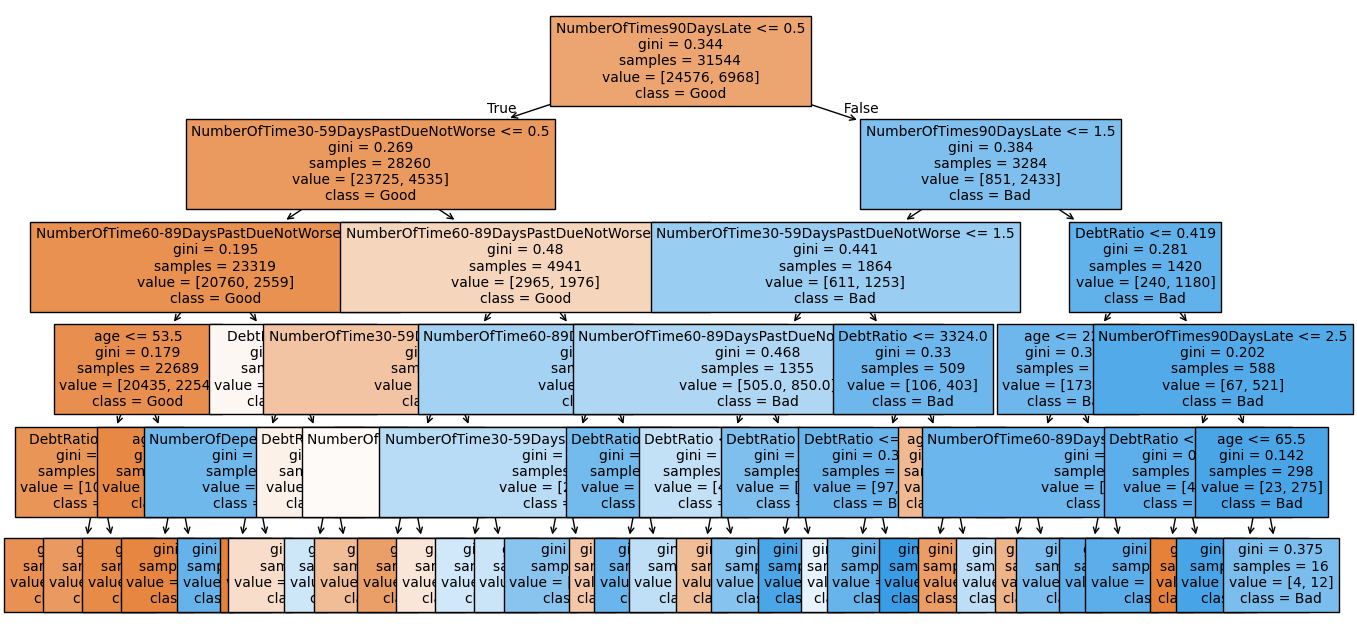

In [ ]:
plt.figure(figsize=(16,8))
tree.plot_tree(clf, feature_names=features, class_names=["Good","Bad"], filled=True, fontsize=10)
plt.show()